In [68]:
import pandas as pd

df = pd.read_csv('D:\Downloads\olymp.csv')
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


<AxesSubplot:ylabel='Frequency'>

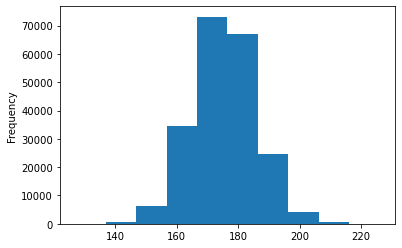

In [60]:
df['Height'].plot(kind = 'hist')

<AxesSubplot:ylabel='Frequency'>

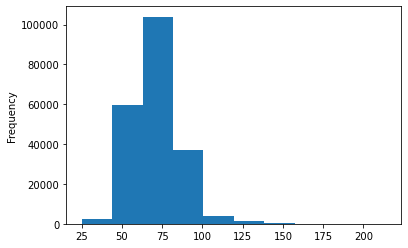

In [62]:
df['Weight'].plot(kind = 'hist')

In [63]:
import numpy as np
avg = df['Height'].mean()
_std1 = avg - df['Height'].std()
_std2 = avg - 2*df['Height'].std()
_std3 = avg - 3*df['Height'].std()
std1 = avg + df['Height'].std()
std2 = avg + 2*df['Height'].std()
std3 = avg + 3*df['Height'].std()

np.array([_std3, _std2, _std1, avg, std1, std2, std3]).round(2)

array([143.78, 154.3 , 164.82, 175.34, 185.86, 196.38, 206.89])

In [66]:
df[df['Sport'] == 'Art Competitions'].drop_duplicates('ID')['Year'].mode()

0    1932
dtype: int64

In [70]:
df['AC'] = df['Sport'].apply(lambda x: x if x == 'Art Competitions' else 'Other')
df[df['AC'] == 'Other'].shape[0]

267538

In [71]:
df['AC'].value_counts()

Other               267538
Art Competitions      3578
Name: AC, dtype: int64

In [72]:
fltr = df[df['Year'] == 1932]
fltr.groupby('AC')['Age'].agg(['mean', 'median', 'std'])

,mean,median,std
AC,,,
Art Competitions,46.937931,47.0,13.278205
Other,25.207996,24.0,6.106876


In [74]:
round(df['Weight'].var(), 2)

205.87

In [75]:
df['Year'].max()-df['Year'].min()

120

In [76]:
df['Age'].median()

24.0

In [77]:
q1 = df['Height'].quantile(0.25)
q3 = df['Height'].quantile(0.75)
iqr = q3 - q1
iqr

15.0

In [79]:
df[df['Medal'] == 'Gold']['Name'].mode()

0    Michael Fred Phelps, II
dtype: object

In [81]:
round(df[df['Sport'] == 'Boxing']['Age'].std(), 2)

3.44

In [86]:
df[df['Season'] == 'Winter'].sort_values('Year').iloc[0]['City']

'Chamonix'

In [88]:
df[df['Season'] == 'Winter'].sort_values('Year').loc[176120]['City']

'Chamonix'

In [95]:
q1 = df.groupby('NOC')['Height'].quantile(0.25)
q3 = df.groupby('NOC')['Height'].quantile(0.75)
iqr = q3 - q1
iqr[iqr == 8].shape[0]

11

In [97]:
df.isna().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
AC             0
dtype: int64

In [100]:
df.isna().mean()*100

ID         0.000000
Name       0.000000
Sex        0.000000
Age        3.494445
Height    22.193821
Weight    23.191180
Team       0.000000
NOC        0.000000
Games      0.000000
Year       0.000000
Season     0.000000
City       0.000000
Sport      0.000000
Event      0.000000
Medal     85.326207
AC         0.000000
dtype: float64

In [101]:
med = df['Height'].median()
df['Height_na'] = df['Height'].fillna(med)
round(abs(df['Height'].mean()-df['Height_na'].mean()), 2)

0.08

In [102]:
med = df['Weight'].median()
df['Weight_na'] = df['Weight'].fillna(med)
round(df['Weight'].mean()*df['Weight_na'].mean(), 2)

4987.31

In [103]:
round(df['Weight'].min()) #1

25

In [106]:
q1 = df['Weight'].quantile(0.25)
round(q1) #3

60

In [107]:
df['Weight'].median() #4

70.0

In [108]:
q3 = df['Weight'].quantile(0.75)
round(q3) #5

79

In [110]:
iqr = q3-q1
left = q1 - 1.5*iqr
round(left) #2

32

In [111]:
right = q3 + 1.5*iqr
round(right) #6

108

In [112]:
df['Weight'].max() #7

214.0

In [114]:
df[(df['Weight']<left) | (df['Weight']>right)].shape[0]

3237

In [115]:
avg = df['Height'].mean()
std = df['Height'].std()

left = avg - std
right = avg + std

df[(df['Height']>left) & (df['Height']<right)].shape[0]

146331